<a href="https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/01_iris_colab_setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Iris Dataset Colab Setup

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/01_iris_colab_setup.ipynb)

이 노트북은 GitHub에서 Colab으로 열어 실행하는 첫 번째 Iris 실습 환경 점검용입니다.

**대상**
- 양자 ML 과정에서 Iris 데이터셋으로 분류 실습을 시작하는 학습자
- Colab 런타임과 GitHub 노트북 실행 흐름을 확인하려는 학습자

**선수 지식**
- Python 기본 문법
- pandas DataFrame 읽기
- 분류 문제에서 train/test split의 의미

**학습 목표**
- Colab 런타임과 기본 분석 패키지 버전을 확인한다.
- `sklearn.datasets.load_iris`로 데이터를 불러오고 구조를 해석한다.
- 표준화 + 로지스틱 회귀 기준 모델을 학습하고 평가한다.
- 이후 양자 ML 실습에서 비교할 classical baseline을 만든다.
- 로컬 설치 없이 GitHub에서 Colab으로 열어 실행하는 흐름을 확인한다.


## Outline

1. Colab runtime and package check
2. Iris dataset loading and inspection
3. Classical baseline training
4. Exercise: replace the baseline with k-nearest neighbors
5. Pitfalls and next extensions


## 1. Runtime check

첫 셀은 숨은 상태 없이 매번 같은 결과를 만들기 위한 기본 설정입니다. Colab에서 실행하면 Python, NumPy, pandas, scikit-learn 버전을 표로 확인할 수 있습니다.


In [1]:
from __future__ import annotations

import platform
import sys
from importlib.metadata import PackageNotFoundError, version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

try:
    from IPython.display import display
except ImportError:
    display = print

RANDOM_STATE = 42


def package_version(package_name: str) -> str:
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "not installed"


env_report = pd.DataFrame(
    [
        {"item": "python", "version": sys.version.split()[0]},
        {"item": "platform", "version": platform.platform()},
        {"item": "numpy", "version": np.__version__},
        {"item": "pandas", "version": pd.__version__},
        {"item": "scikit-learn", "version": sklearn.__version__},
        {"item": "matplotlib", "version": package_version("matplotlib")},
    ]
)

env_report


,item,version
0,python,3.12.13
1,platform,Linux-6.6.122+-x86_64-with-glibc2.35
2,numpy,2.0.2
3,pandas,2.2.2
4,scikit-learn,1.6.1
5,matplotlib,3.10.0


## 2. Load the Iris dataset

Iris는 150개 샘플, 4개 연속형 특성, 3개 품종 클래스로 구성된 작은 분류 데이터셋입니다. 데이터가 작기 때문에 환경 점검과 모델 파이프라인 연습에 적합합니다.


In [2]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
features = iris.data
labels = iris.target
class_names = dict(enumerate(iris.target_names))

iris_df = features.copy()
iris_df["species_id"] = labels
iris_df["species"] = labels.map(class_names)

dataset_summary = pd.DataFrame(
    [
        {"item": "rows", "value": len(iris_df)},
        {"item": "features", "value": features.shape[1]},
        {"item": "classes", "value": len(iris.target_names)},
        {"item": "class_names", "value": ", ".join(iris.target_names)},
    ]
)

dataset_summary


,item,value
0,rows,150
1,features,4
2,classes,3
3,class_names,"setosa, versicolor, virginica"


## 3. Inspect the data

처음에는 큰 표보다 작은 미리보기와 클래스별 요약 통계가 더 유용합니다. 양자 ML 실습에서도 입력 특성의 스케일과 클래스 분포는 먼저 확인해야 합니다.


In [3]:
display(iris_df.head())

class_counts = iris_df["species"].value_counts().rename_axis("species").reset_index(name="count")
display(class_counts)

feature_summary = iris_df.groupby("species")[iris.feature_names].agg(["mean", "std"]).round(2)
display(feature_summary)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


,species,count
0,setosa,50
1,versicolor,50
2,virginica,50


sepal length (cm)       sepal width (cm)       petal length (cm)  \
                        mean   std             mean   std              mean   
species                                                                       
setosa                  5.01  0.35             3.43  0.38              1.46   
versicolor              5.94  0.52             2.77  0.31              4.26   
virginica               6.59  0.64             2.97  0.32              5.55   

                 petal width (cm)        
             std             mean   std  
species                                  
setosa      0.17             0.25  0.11  
versicolor  0.47             1.33  0.20  
virginica   0.55             2.03  0.27

## 4. Quick visualization

아래 산점도는 `setosa`가 다른 두 품종보다 쉽게 분리되는 이유를 직관적으로 보여줍니다. 나머지 두 품종은 더 많이 겹치므로 모델 평가가 필요합니다.


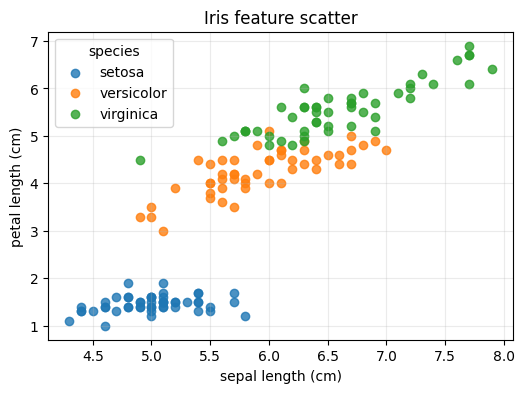

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))

for species, group in iris_df.groupby("species"):
    ax.scatter(
        group["sepal length (cm)"],
        group["petal length (cm)"],
        label=species,
        alpha=0.8,
    )

ax.set_title("Iris feature scatter")
ax.set_xlabel("sepal length (cm)")
ax.set_ylabel("petal length (cm)")
ax.legend(title="species")
ax.grid(alpha=0.25)
plt.show()


## 5. Train a classical baseline

기준 모델은 `StandardScaler`와 `LogisticRegression`을 하나의 pipeline으로 묶습니다. 이렇게 하면 학습 데이터에 맞춘 스케일링 규칙이 테스트 데이터에만 적용되어 데이터 누수를 줄일 수 있습니다.


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.25,
    stratify=labels,
    random_state=RANDOM_STATE,
)

baseline_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=200, random_state=RANDOM_STATE),
)
baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print(f"Train samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Baseline test accuracy: {baseline_accuracy:.3f}")
print()
print(classification_report(y_test, baseline_predictions, target_names=iris.target_names))


Train samples: 112
Test samples: 38
Baseline test accuracy: 0.921

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



## 6. Read the errors

정확도 하나만 보면 어떤 품종에서 혼동이 생겼는지 알기 어렵습니다. Confusion matrix를 보면 실제 클래스와 예측 클래스의 대응을 확인할 수 있습니다.


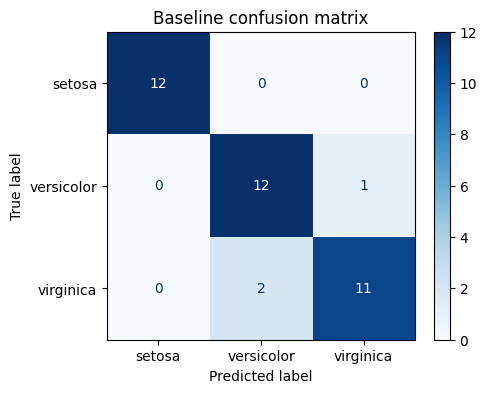

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    baseline_predictions,
    display_labels=iris.target_names,
    cmap="Blues",
    ax=ax,
)
ax.set_title("Baseline confusion matrix")
plt.show()


## 7. Interpretation

이 baseline은 이후 양자 ML 모델과 비교할 기준점입니다. 다음 실습에서 quantum feature map, quantum kernel, variational classifier 등을 도입하더라도 먼저 같은 train/test split과 같은 평가 지표를 유지해야 비교가 의미 있습니다.


## Exercise: replace the model with k-nearest neighbors

아래 셀은 같은 전처리와 같은 train/test split을 유지한 채 분류기만 바꾸는 연습입니다. `n_neighbors` 값을 1, 3, 5, 7로 바꾸며 정확도가 어떻게 달라지는지 확인하세요.


In [7]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5),
)
knn_model.fit(X_train, y_train)

knn_predictions = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_predictions)

comparison = pd.DataFrame(
    [
        {"model": "logistic_regression", "test_accuracy": baseline_accuracy},
        {"model": "knn_k5", "test_accuracy": knn_accuracy},
    ]
).sort_values("test_accuracy", ascending=False)

comparison


,model,test_accuracy
0,logistic_regression,0.921053
1,knn_k5,0.921053


## Pitfalls and next extensions

**Common pitfall**: 전체 데이터에 `StandardScaler`를 먼저 fit한 뒤 train/test split을 하면 테스트 데이터 정보가 학습 과정에 새어 들어갑니다. 위처럼 pipeline을 만들고 train split에만 fit하세요.

**Next extension**: 다음 노트북에서는 같은 Iris split을 유지한 채 입력 특성을 2개로 줄이고, 필요한 양자 ML 패키지는 Colab 노트북 안에서 명시적으로 다룬 뒤 quantum feature map 또는 quantum kernel로 바꿔 classical baseline과 비교합니다.
